In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

sns.set(style="whitegrid")

In [2]:
from pathlib import Path
from kaggle.api.kaggle_api_extended import KaggleApi

data_dir = Path("../data")
data_dir.mkdir(parents=True, exist_ok=True)

api = KaggleApi()
api.authenticate()
api.dataset_download_files("alexandersemiletov/toxic-russian-comments", path=str(data_dir), unzip=True)

Dataset URL: https://www.kaggle.com/datasets/alexandersemiletov/toxic-russian-comments


In [3]:
data_list = []
with open("../data/dataset.txt", encoding="utf-8") as file:
    for line in file:
        labels = line.split()[0]
        text = line[len(labels) + 1:].strip()
        labels = labels.split(",")
        mask = [
            1 if "__label__NORMAL" in labels else 0,
            1 if "__label__INSULT" in labels else 0,
            1 if "__label__THREAT" in labels else 0,
            1 if "__label__OBSCENITY" in labels else 0,
        ]
        data_list.append((text, *mask))

In [4]:
df = pd.DataFrame(data_list, columns=["text", "normal", "insult", "threat", "obscenity"])

In [5]:
df.head()

,text,normal,insult,threat,obscenity
0,скотина! что сказать,0,1,0,0
1,я сегодня проезжала по рабочей и между домами ...,1,0,0,0
2,очередной лохотрон. зачем придумывать очередно...,1,0,0,0
3,"ретро дежавю ... сложно понять чужое сердце , ...",1,0,0,0
4,а когда мы статус агрогородка получили?,1,0,0,0


In [6]:
df.shape

(248290, 5)

In [7]:
df.describe(include='all')

,text,normal,insult,threat,obscenity
count,248290,248290.000000,248290.000000,248290.000000,248290.000000
unique,248283,NaN,NaN,NaN,NaN
top,сжечь,NaN,NaN,NaN,NaN
freq,2,NaN,NaN,NaN,NaN
mean,NaN,0.820351,0.148318,0.048439,0.017161
std,NaN,0.383895,0.355416,0.214693,0.129873
min,NaN,0.000000,0.000000,0.000000,0.000000
25%,NaN,1.000000,0.000000,0.000000,0.000000
50%,NaN,1.000000,0.000000,0.000000,0.000000
75%,NaN,1.000000,0.000000,0.000000,0.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248290 entries, 0 to 248289
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   text       248290 non-null  object
 1   normal     248290 non-null  int64 
 2   insult     248290 non-null  int64 
 3   threat     248290 non-null  int64 
 4   obscenity  248290 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 9.5+ MB


In [9]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
text         0
normal       0
insult       0
threat       0
obscenity    0
dtype: int64


In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 6


In [42]:
print("Duplicate texts:", df["text"].duplicated().sum())


duplicated_texts = df[df.duplicated(subset=['text'], keep=False)]


inconsistent = []
for text, group in duplicated_texts.groupby('text'):

    if (group['normal'].nunique() > 1 or
        group['insult'].nunique() > 1 or
        group['threat'].nunique() > 1 or
        group['obscenity'].nunique() > 1):
        inconsistent.append(group)


result = pd.concat(inconsistent).sort_values(['text', 'normal', 'insult', 'threat', 'obscenity'])

print("Duplicated texts with different labels:")
display(result)

Duplicate texts: 7
Duplicated texts with different labels:


,text,normal,insult,threat,obscenity,label_sum,label_combo,text_len_chars,text_len_words,text_clean
230339,сжечь,0,0,1,0,1,threat,5,1,сжечь
218287,сжечь,1,0,0,0,1,normal,5,1,сжечь


In [12]:
print("Duplicate texts with same labels:", df.duplicated(subset=["text", "normal", "insult", "threat", "obscenity"]).sum())

Duplicate texts with same labels: 6


Распределение классов

In [13]:
label_cols = ["normal", "insult", "threat", "obscenity"]

label_counts = df[label_cols].sum().sort_values(ascending=False)
label_counts

normal       203685
insult        36826
threat        12027
obscenity      4261
dtype: int64

C:\Users\valentin\AppData\Local\Temp\ipykernel_3420\4037341960.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


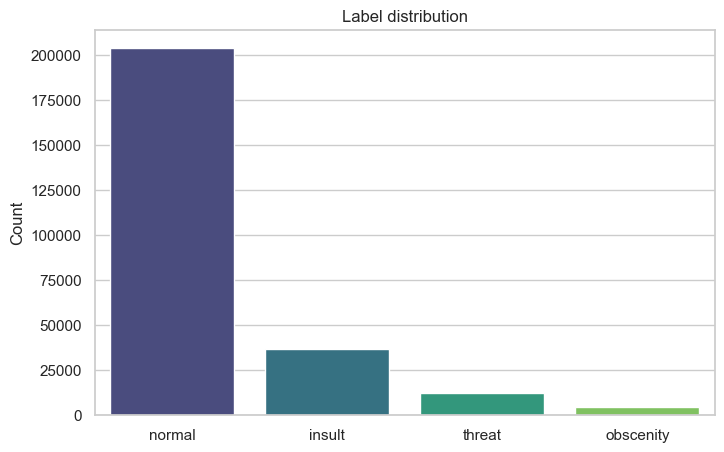

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")
plt.title("Label distribution")
plt.xlabel("")
plt.ylabel("Count")
plt.show()

Доля каждого класса

In [15]:
label_share = (df[label_cols].sum() / len(df) * 100).sort_values(ascending=False)
label_share

normal       82.035120
insult       14.831850
threat        4.843932
obscenity     1.716138
dtype: float64

C:\Users\valentin\AppData\Local\Temp\ipykernel_3420\3666977205.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_share.index, y=label_share.values, palette="magma")


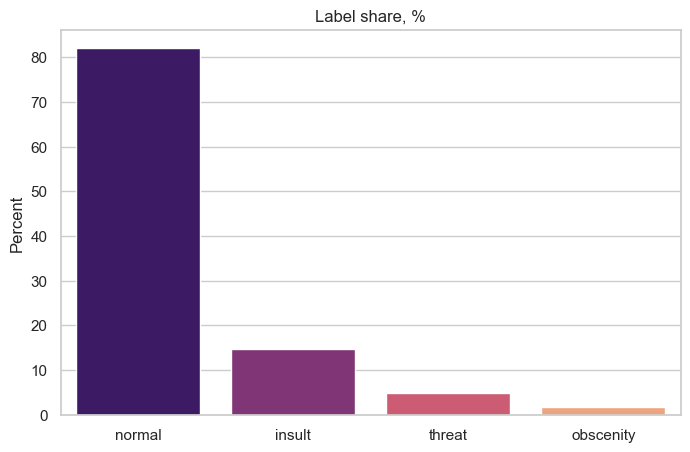

In [16]:
plt.figure(figsize=(8, 5))
sns.barplot(x=label_share.index, y=label_share.values, palette="magma")
plt.title("Label share, %")
plt.xlabel("")
plt.ylabel("Percent")
plt.show()

Количество меток на один текст

In [17]:
df["label_sum"] = df[label_cols].sum(axis=1)
df["label_sum"].value_counts().sort_index()

label_sum
1    239957
2      8157
3       176
Name: count, dtype: int64

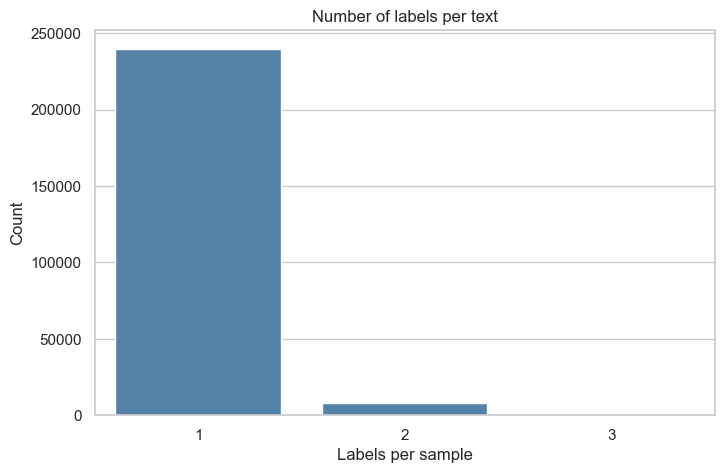

In [18]:
plt.figure(figsize=(8, 5))
sns.countplot(x=df["label_sum"], color="steelblue")
plt.title("Number of labels per text")
plt.xlabel("Labels per sample")
plt.ylabel("Count")
plt.show()

Сочетания меток

In [19]:
def get_label_combination(row):
    labels = [col for col in label_cols if row[col] == 1]
    return ", ".join(labels) if labels else "none"

df["label_combo"] = df.apply(get_label_combination, axis=1)

In [20]:
combo_counts = df["label_combo"].value_counts()
combo_counts.head(20)

label_combo
normal                       203685
insult                        28567
insult, threat                 6317
threat                         5460
obscenity                      2245
insult, obscenity              1766
insult, threat, obscenity       176
threat, obscenity                74
Name: count, dtype: int64

C:\Users\valentin\AppData\Local\Temp\ipykernel_3420\967978325.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=combo_counts.head(15).index, x=combo_counts.head(15).values, palette="crest")


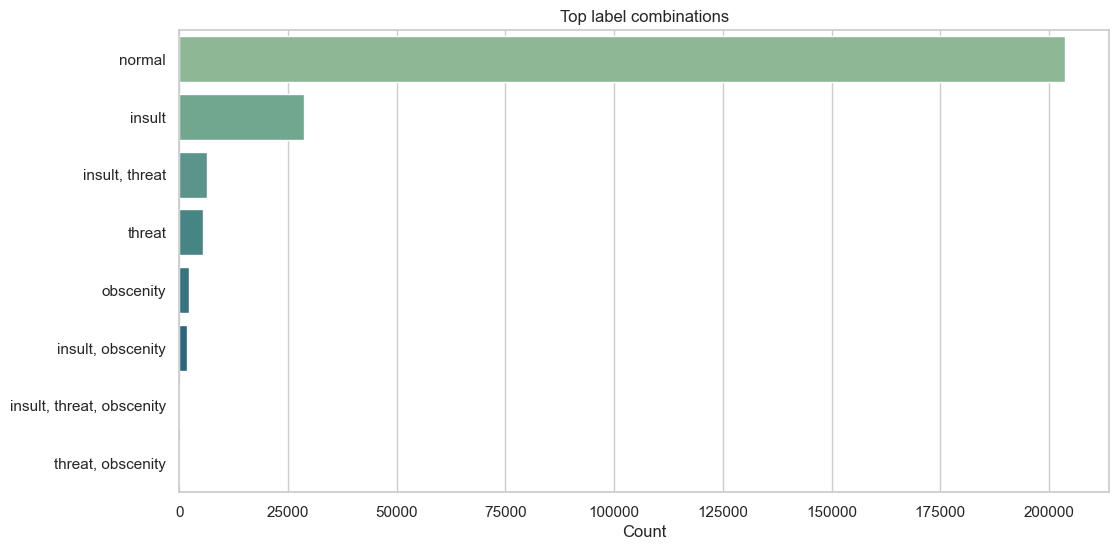

In [21]:
plt.figure(figsize=(12, 6))
sns.barplot(y=combo_counts.head(15).index, x=combo_counts.head(15).values, palette="crest")
plt.title("Top label combinations")
plt.xlabel("Count")
plt.ylabel("")
plt.show()

Тексты и длина

In [22]:
df["text_len_chars"] = df["text"].astype(str).str.len()
df["text_len_words"] = df["text"].astype(str).str.split().apply(len)

In [23]:
df[["text_len_chars", "text_len_words"]].describe()

,text_len_chars,text_len_words
count,248290.000000,248290.000000
mean,78.095191,12.500230
std,96.385933,15.419661
min,2.000000,1.000000
25%,27.000000,4.000000
50%,47.000000,8.000000
75%,88.000000,14.000000
max,998.000000,267.000000


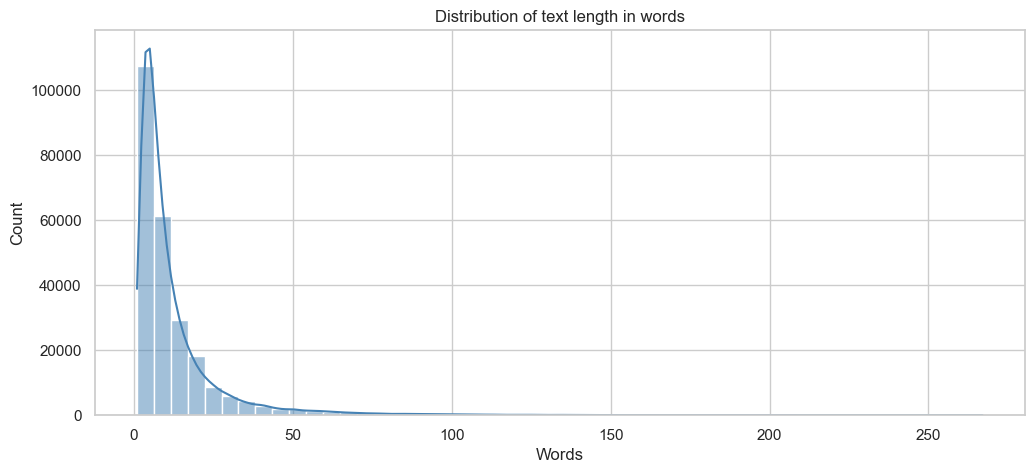

In [24]:
plt.figure(figsize=(12, 5))
sns.histplot(df["text_len_words"], bins=50, kde=True, color="steelblue")
plt.title("Distribution of text length in words")
plt.xlabel("Words")
plt.ylabel("Count")
plt.show()

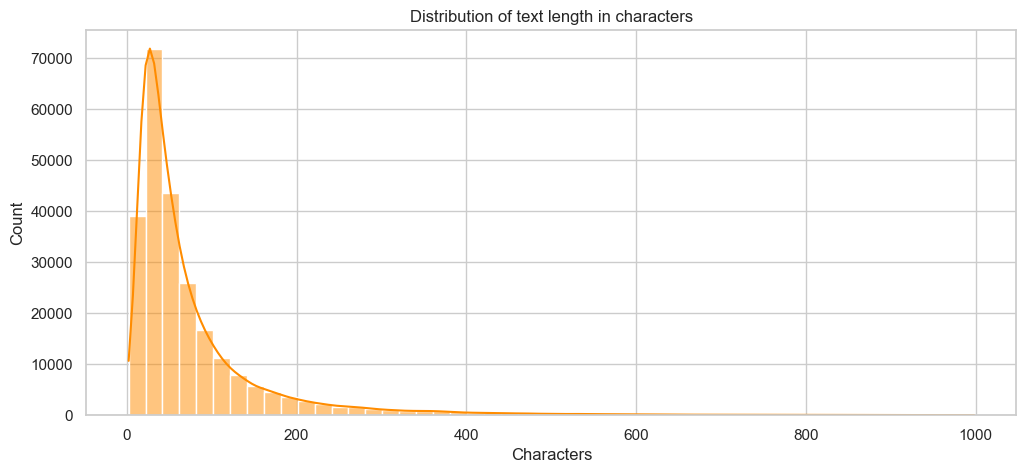

In [25]:
plt.figure(figsize=(12, 5))
sns.histplot(df["text_len_chars"], bins=50, kde=True, color="darkorange")
plt.title("Distribution of text length in characters")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.show()

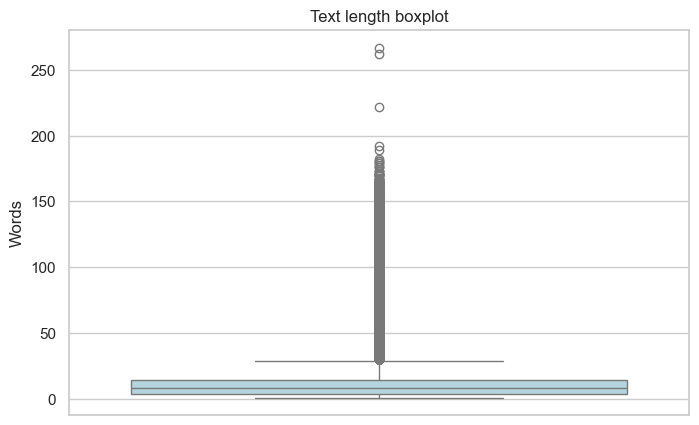

In [26]:
plt.figure(figsize=(8, 5))
sns.boxplot(y=df["text_len_words"], color="lightblue")
plt.title("Text length boxplot")
plt.ylabel("Words")
plt.show()

Длина текста по меткам

In [27]:
length_by_label = []
for label in label_cols:
    tmp = df[df[label] == 1][["text_len_words"]].copy()
    tmp["label"] = label
    length_by_label.append(tmp)

length_by_label = pd.concat(length_by_label, ignore_index=True)
length_by_label.head()

,text_len_words,label
0,29,normal
1,54,normal
2,12,normal
3,6,normal
4,23,normal


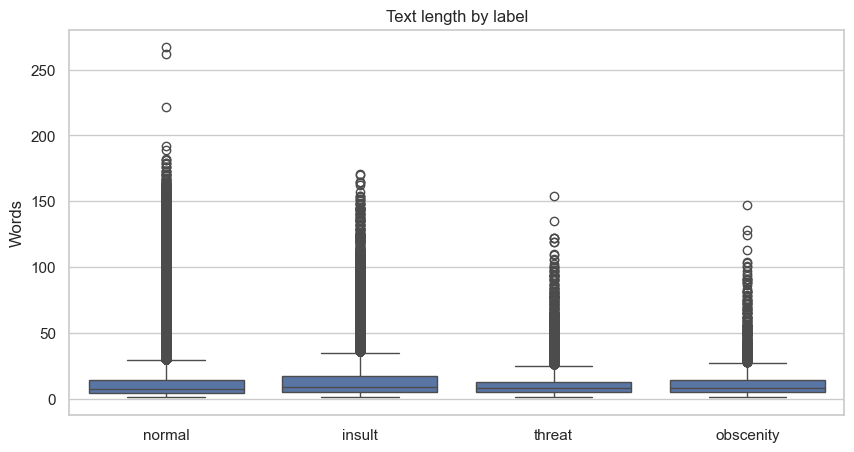

In [28]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=length_by_label, x="label", y="text_len_words")
plt.title("Text length by label")
plt.xlabel("")
plt.ylabel("Words")
plt.show()

Частые слова

In [29]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"[^а-яёa-z0-9\s-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [30]:
df["text_clean"] = df["text"].apply(preprocess_text)

In [31]:
all_words = " ".join(df["text_clean"]).split()
word_counter = Counter(all_words)

top_words = pd.DataFrame(word_counter.most_common(20), columns=["word", "count"])
top_words

,word,count
0,и,105621
1,не,80617
2,в,76453
3,а,49202
4,на,45135
5,что,34987
6,с,33813
7,это,29410
8,я,24657
9,как,23624


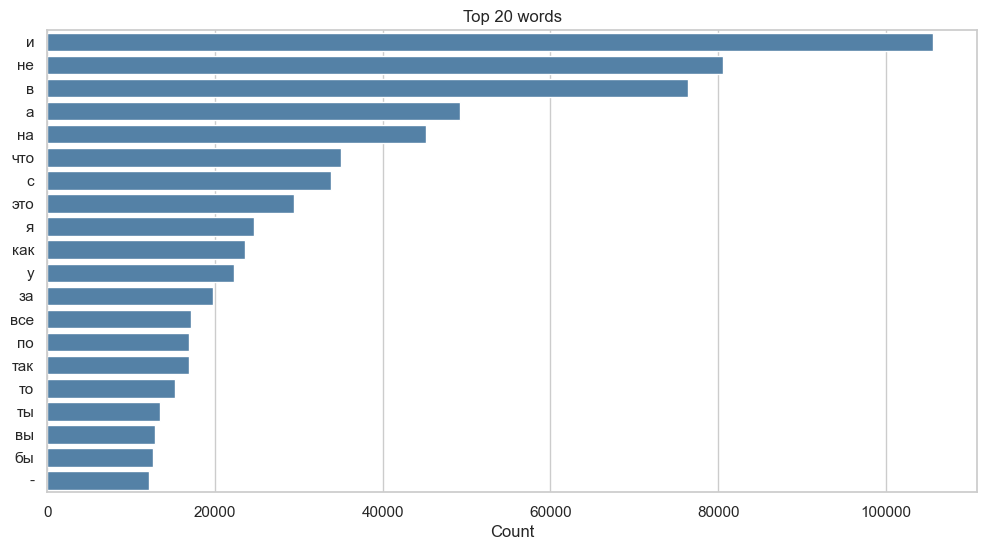

In [32]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_words, y="word", x="count", color="steelblue")
plt.title("Top 20 words")
plt.xlabel("Count")
plt.ylabel("")
plt.show()

Частые биграммы

In [33]:
def get_top_ngrams(text_series, n=2, top_k=20):
    vectorizer = CountVectorizer(ngram_range=(n, n))
    X = vectorizer.fit_transform(text_series)
    freqs = X.sum(axis=0).A1
    ngrams = vectorizer.get_feature_names_out()
    result = pd.DataFrame({"ngram": ngrams, "count": freqs})
    return result.sort_values("count", ascending=False).head(top_k)

In [34]:
top_bigrams = get_top_ngrams(df["text_clean"], n=2, top_k=20)
top_bigrams

,ngram,count
1507931,это не,2180
1476702,что то,1931
1333496,то что,1748
29151,ok ru,1573
747437,не было,1445
754565,не надо,1406
281617,дай бог,1336
1007637,потому что,1334
794652,ничего не,1297
1473427,что не,1237


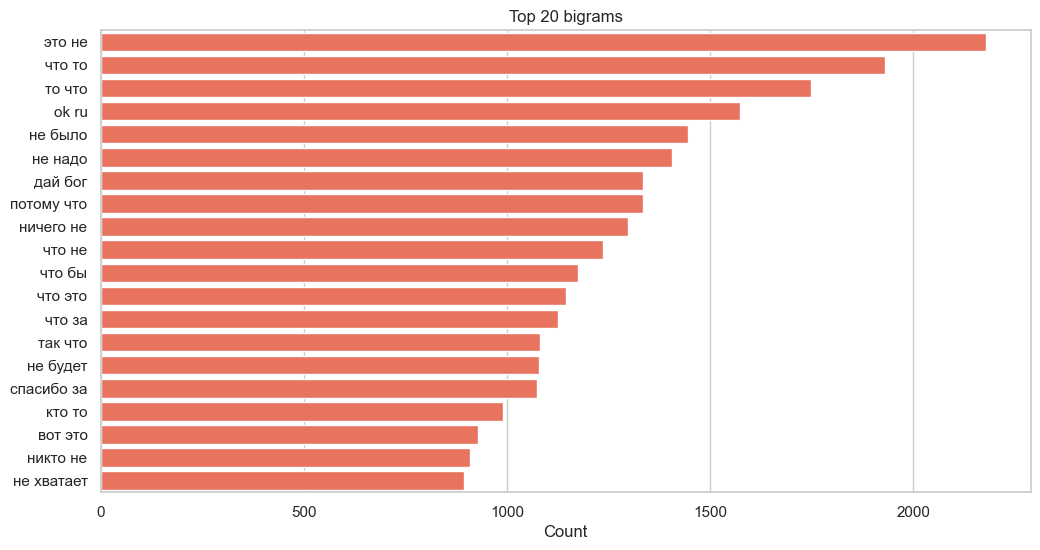

In [35]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_bigrams, y="ngram", x="count", color="tomato")
plt.title("Top 20 bigrams")
plt.xlabel("Count")
plt.ylabel("")
plt.show()